# Setup

In [ ]:
%load_ext autoreload
%autoreload 2
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import healpy as hp
import rubin_sim.maf as maf
import rubin_scheduler.utils as rsUtils
import rubin_sim.data as data
import astropy.units as u
from astropy.coordinates import SkyCoord
from rubin_scheduler.utils import ra_dec2_hpid, hpid2_ra_dec
from rubin_scheduler.scheduler.utils import CurrentAreaMap, SkyAreaGeneratorGalplane, SkyAreaGenerator
from rubin_scheduler.scheduler.utils import EuclidOverlapFootprint
import astropy.io.fits as fits
from astropy.table import Table
from astropy.time import Time
import datetime as dt
import pytz
import matplotlib.dates as mdates
# Add Skyfield directory to path to avoid conflicts
sys.path.insert(0, os.path.join(os.getcwd(), 'Skyfield', 'src'))
from utils import utils

### OpSim

Set the OpSim database directory.

In [17]:

# Set RUBIN_SIM_DATA_DIR environment variable
os.environ['RUBIN_SIM_DATA_DIR'] = '/data/a.saricaoglu/repo/RubinsForge/rubin_sim_data'
print(f"Current working directory: {os.getcwd()}")
print(f"RUBIN_SIM_DATA_DIR set to: {os.environ.get('RUBIN_SIM_DATA_DIR')}")
print(f'version of rubin_sim: {data.data_dict()}')


Current working directory: /data/a.saricaoglu/repo/RubinsForge
RUBIN_SIM_DATA_DIR set to: /data/a.saricaoglu/repo/RubinsForge/rubin_sim_data
version of rubin_sim: {'maf': 'maf_2024_06_13.tgz', 'maps': 'maps_2022_2_28.tgz', 'movingObjects': 'movingObjects_oct_2021.tgz', 'orbits': 'orbits_2022_3_1.tgz', 'orbits_precompute': 'orbits_precompute_2023_05_23.tgz', 'sim_baseline': 'sim_baseline_2025_03_03.tgz', 'skybrightness': 'skybrightness_2023_09_11.tgz', 'throughputs': 'throughputs_2023_09_22.tgz', 'tests': 'tests_2024_04_23.tgz'}


Import the baseline simulation. 

In [18]:

db_dir = os.path.join(os.environ['RUBIN_SIM_DATA_DIR'], 'sim_baseline')
db_files = [f for f in os.listdir(db_dir) if f.endswith('.db') and f != 'baseline.db']

if db_files:
    baseline_file = os.path.join(db_dir, db_files[0])
    print(f"Using database: {baseline_file}")
else:
    print("No database files found!")
    baseline_file = None

if baseline_file and os.path.exists(baseline_file):
    name = os.path.basename(baseline_file).replace('.db','')
    out_dir = 'temp'
    results_db = maf.db.ResultsDb(out_dir=out_dir)
    print(f"Successfully using baseline database: {baseline_file}")
else:
    print(f"Database file not found: {baseline_file}")

Using database: /data/a.saricaoglu/repo/RubinsForge/rubin_sim_data/sim_baseline/baseline_v4.3.1_10yrs.db
Successfully using baseline database: /data/a.saricaoglu/repo/RubinsForge/rubin_sim_data/sim_baseline/baseline_v4.3.1_10yrs.db


If there are multiple baselines on the directory, choose one manually.

In [19]:
baseline_file = '/data/a.saricaoglu/repo/RubinsForge/rubin_sim_data/sim_baseline/baseline_v5.0.1_10yrs.db'
name = os.path.basename(baseline_file).replace('.db','')
out_dir = 'v5.0.1_10yrs'
results_db = maf.db.ResultsDb(out_dir=out_dir)
print(f"Using baseline database: {baseline_file}")
print(results_db)

Using baseline database: /data/a.saricaoglu/repo/RubinsForge/rubin_sim_data/sim_baseline/baseline_v5.0.1_10yrs.db


### Targets

Read targets from the .fits file we created in the first tutorial.

In [34]:
pathToTargets = os.path.join(os.getcwd(), 'in_LSST_footprint_coordinates.fits')
targets = utils.get_targets_as_dataframe(pathToTargets)
target_coordinates = utils.get_targets_as_coordinates(pathToTargets)

Filename: /data/a.saricaoglu/repo/RubinsForge/in_LSST_footprint_coordinates.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  In_LSST_Footprint    1 BinTableHDU     21   13740R x 4C   [12A, 28A, D, D]   
  2  In_Euclid_Lowdust_Region    1 BinTableHDU     21   13019R x 4C   [12A, 28A, D, D]   


Loaded 13740 target coordinates from /data/a.saricaoglu/repo/RubinsForge/in_LSST_footprint_coordinates.fits
Filename: /data/a.saricaoglu/repo/RubinsForge/in_LSST_footprint_coordinates.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  In_LSST_Footprint    1 BinTableHDU     21   13740R x 4C   [12A, 28A, D, D]   
  2  In_Euclid_Lowdust_Region    1 BinTableHDU     21   13019R x 4C   [12A, 28A, D, D]   
Loaded 13740 target coordinates from /data/a.saricaoglu/repo/RubinsForge/in_LSST_footprint_coordinates.fits


# Twilight Windows

Since we are interested in the twilight visits, we need to know when twilight starts and ends for each day in the simulation. We use a function that provides this info for a given start and end date. create_exposure_windows() function saves the twilight windows into a .npz file, under 'files/twilight_windows' directory.

In [ ]:
# Provide start and end date as a datetime() object.
year_start, month_start, day_start = 2026, 3, 1
year_end, month_end, day_end = 2026, 3, 31
obs_start = dt.datetime(year_start, month_start, day_start, 0, 0, 0, 0)
obs_end = dt.datetime(year_end, month_end, day_end, 0, 0, 0, 0)

twilight_windows_file = utils.create_twilight_windows(obs_start, obs_end)

2026-03-01 06:11 mjd 61100.382968792226 Astronomical twilight starts
2026-03-01 06:40 mjd 61100.403301911894 Nautical twilight starts
2026-03-01 07:09 mjd 61100.4232197986 Civil twilight starts
2026-03-01 07:33 mjd 61100.44013996236 Day starts
2026-03-01 20:16 mjd 61100.96959331818 Day ends
2026-03-01 20:40 mjd 61100.986478132196 Civil twilight ends
2026-03-01 21:09 mjd 61101.00634574564 Nautical twilight ends
2026-03-01 21:38 mjd 61101.02661485784 Astronomical twilight ends
2026-03-02 06:12 mjd 61101.38358185254 Astronomical twilight starts
2026-03-02 06:41 mjd 61101.403859724756 Nautical twilight starts
2026-03-02 07:10 mjd 61101.42373786541 Civil twilight starts
2026-03-02 07:34 mjd 61101.440633489285 Day starts
2026-03-02 20:15 mjd 61101.968818674795 Day ends
2026-03-02 20:39 mjd 61101.985679528676 Civil twilight ends
2026-03-02 21:07 mjd 61102.005508270115 Nautical twilight ends
2026-03-02 21:37 mjd 61102.02572333533 Astronomical twilight ends
2026-03-03 06:13 mjd 61102.3841867488

# OpSim Bundles

Now we collect the visits from OpSim exposures that observe any targets from our target list.
First, construct the MetricBundle that holds the metadata of those visits.

In [35]:
bundle_list = []

# Get coordinates from targets dictionary
ra, dec = target_coordinates.ra.degree, target_coordinates.dec.degree

print(f"Setting up MAF analysis for {len(target_coordinates)} targets")
print(f"RA range: {ra.min():.3f}° to {ra.max():.3f}°")
print(f"Dec range: {dec.min():.3f}° to {dec.max():.3f}°")

# Say we just want to pass data through, not compute anything. Documentation on 
# columns at:  https://rubin-sim.lsst.io/rs_scheduler/output_schema.html
metric = maf.metrics.PassMetric(cols=['observationID','fieldRA','fieldDec', 'filter', 'observationStartMJD', 'fiveSigmaDepth', 'visitExposureTime', 'numExposures', 'seeingFwhm500',
'seeingFwhmEff', 'skyBrightness','target_name'])

# Select all the visits. Could be something like "filter='r'", "night < 365", etc
sql = ''
slicer = maf.slicers.UserPointsSlicer(ra=ra, dec=dec)
bundle_list.append(maf.MetricBundle(metric, slicer, sql, run_name=name))

print(f"Created MetricBundle for {len(ra)} target positions")

Setting up MAF analysis for 13740 targets
RA range: 0.031° to 359.985°
Dec range: -85.747° to 33.117°
Created MetricBundle for 13740 target positions


Then, run the MetricBundle to retrieve data for these visits.

In [36]:
bd = maf.metricBundles.make_bundles_dict_from_list(bundle_list)
bg = maf.metricBundles.MetricBundleGroup(bd, baseline_file, out_dir=out_dir, results_db=results_db)
bg.run_all()


Our bundleList now has values. The trailing [0] is to get the first result. If we specified more ra,dec point, those results would be in the later indices.
Let's find the date of the first observation.

In [43]:
print(f'Length of the bundle list is {len(bundle_list[0].metric_values)}')
first_obs_dates = []
for point in bundle_list[0].metric_values:
    first_obs_dates.append(np.min(point['observationStartMJD']))

# Convert to Chile timezone using pytz
earliest_mjd = np.min(first_obs_dates)
earliest_time = Time(earliest_mjd, format='mjd')

# Get Chile timezone
chile_tz = pytz.timezone('Chile/Continental')  # or 'Chile/Continental'

# Convert to datetime in UTC first, then localize to Chile
utc_datetime = earliest_time.to_datetime(timezone=dt.timezone.utc)
chile_datetime = utc_datetime.astimezone(chile_tz)

print(f"Earliest observation in dataset: MJD {earliest_mjd:.3f}")
print(f"Chile time: {chile_datetime.strftime('%Y-%m-%d %H:%M:%S %Z')}")
print(f"UTC time: {utc_datetime.strftime('%Y-%m-%d %H:%M:%S %Z')}")

Length of the bundle list is 13740
Earliest observation in dataset: MJD 60981.026
Chile time: 2025-11-01 21:38:07 -03
UTC time: 2025-11-02 00:38:07 UTC


We collect visits that are within our observation period, which we've constructed the twilight windows.

In [58]:
print(f"Getting visit/exposure groups from {obs_start.strftime('%Y-%m-%d_%H:%M:%S %Z')} to {obs_end.strftime('%Y-%m-%d %H:%M:%S %Z')}")
obs_start = dt.datetime(year_start, month_start, day_start, 0, 0, 0, 0, tzinfo=chile_tz)
obs_end = dt.datetime(year_end, month_end, day_end, 0, 0, 0, 0, tzinfo=chile_tz)
start_mjd = Time(obs_start).mjd
end_mjd = Time(obs_end).mjd
# Get targets grouped by visit/exposure
visit_exposure_groups = utils.get_targets_by_visit_exposure(bundle_list, targets, start_mjd, end_mjd)


Getting visit/exposure groups from 2026-03-01_00:00:00 -03 to 2026-03-31 00:00:00 -03


In [52]:
print(len(targets))

13740


In [59]:

# Print summary
print("TARGETS BY VISIT/EXPOSURE GROUPS")
print("="*50)
print(f"Total visit/exposure combinations: {len(visit_exposure_groups)}")

# Show groups with multiple targets
multi_target_groups = {k: v for k, v in visit_exposure_groups.items() if len(v['targets']) > 1}
print(f"Groups with multiple targets: {len(multi_target_groups)}")

# Show first few multi-target groups
for i, (visit_key, group_data) in enumerate(list(multi_target_groups.items())[:1]):
    print(f"\n{visit_key}:")
    print(f"  Visit ID: {group_data['visit_id']}")
    print(f"  MJD: {Time(group_data['mjd'], format='mjd').to_datetime(timezone=chile_tz).strftime('%Y-%m-%d %H:%M:%S %Z')}")
    print(f"  Chile Time: {group_data['chile_time'].strftime('%Y-%m-%d %H:%M:%S %Z')}")
    print(f"  Filter: {group_data['filter']}")
    print(f"  Exposure: {group_data['exposure_time']}s × {group_data['num_exposures']}")
    print(f"  Field center: RA={group_data['field_ra']:.4f}°, Dec={group_data['field_dec']:.4f}°")
    print(f"  Targets ({len(group_data['targets'])}):")
    
    for target in group_data['targets']:
        print(f"    {target['target_id']}: RA={target['target_ra']:.4f}°, Dec={target['target_dec']:.4f}°")
        print(f"      Depth: {target['five_sigma_depth']:.2f}, Seeing: {target['seeing']:.2f}\"")

print(f'Earliest MJD with multiple targets: {Time(np.min([group["mjd"] for group in multi_target_groups.values()]), format="mjd").to_datetime(timezone=chile_tz).strftime("%Y-%m-%d %H:%M:%S %Z")}')

TARGETS BY VISIT/EXPOSURE GROUPS
Total visit/exposure combinations: 0
Groups with multiple targets: 0


ValueError: zero-size array to reduction operation minimum which has no identity

## Load twilight windows for the month

Now we load the twilight windows we saved above. There are 2 twilight windows per day, 'am' and 'pm' twilights.

In [ ]:
twilight_windows = utils.load_twilight_windows(twilight_windows_file, verbose=True)


Loaded 120 twilight events
  1: am twilight start at MJD 61100.382969
  2: am twilight end at MJD 61100.440140
  3: pm twilight start at MJD 61100.969593
  4: pm twilight end at MJD 61101.026615
  5: am twilight start at MJD 61101.383582
  6: am twilight end at MJD 61101.440633
  7: pm twilight start at MJD 61101.968819
  8: pm twilight end at MJD 61102.025723
  9: am twilight start at MJD 61102.384187
  10: am twilight end at MJD 61102.441123
  11: pm twilight start at MJD 61102.968037
  12: pm twilight end at MJD 61103.024829
  13: am twilight start at MJD 61103.384784
  14: am twilight end at MJD 61103.441608
  15: pm twilight start at MJD 61103.967249
  16: pm twilight end at MJD 61104.023932
  17: am twilight start at MJD 61104.385373
  18: am twilight end at MJD 61104.442089
  19: pm twilight start at MJD 61104.966455
  20: pm twilight end at MJD 61105.023033
  21: am twilight start at MJD 61105.385954
  22: am twilight end at MJD 61105.442566
  23: pm twilight start at MJD 61105

Finally, we choose the visits that falls within our twilight windows. These are twilight visits.
However, 'twilight windows' we collected are based on Rubin Observatory's location. Satellites orbiting ~550km might start reflecting the sunlight before or after Rubin's twilight times. Therefore, for my simulations throughout May 25 - April 26, I did 'sampler runs' for each month, sampling the earliest contaminated visit times in every few days. These 'extension' times varies from 1h to 1.6h, shortest for May & June and the longest for December & January. It should be due to the axis tilt of the Earth and it is position on the orbit, however, having data for only one year is not enough to confirm this. One can take 1.5h on average.

In [ ]:
# Now let's check if any visits fall into the twilight windows.
# This function will also add a 'twilight_overlap' key to each visit in the visit_exposure_groups dictionary, 
# which is True if it overlaps with a twilight window and False otherwise.
visit_exposure_groups = utils.find_twilight_window_visit_overlaps(twilight_windows, visit_exposure_groups, extension_time=1.5, verbose=True)


Visit 56211 has a visit at Chile Time 2026-03-13 21:34:19.107831-03:00 which falls within twilight window 2026-03-13 20:02:17.697154-03:00 to 2026-03-13 21:22:45.659903-03:00
Visit 56212 has a visit at Chile Time 2026-03-13 21:35:01.177831-03:00 which falls within twilight window 2026-03-13 20:02:17.697154-03:00 to 2026-03-13 21:22:45.659903-03:00
Visit 56213 has a visit at Chile Time 2026-03-13 21:35:43.247830-03:00 which falls within twilight window 2026-03-13 20:02:17.697154-03:00 to 2026-03-13 21:22:45.659903-03:00
Visit 53937 has a visit at Chile Time 2026-03-09 21:33:41.726472-03:00 which falls within twilight window 2026-03-09 20:07:02.703977-03:00 to 2026-03-09 21:27:58.077923-03:00
Visit 53938 has a visit at Chile Time 2026-03-09 21:34:15.796472-03:00 which falls within twilight window 2026-03-09 20:07:02.703977-03:00 to 2026-03-09 21:27:58.077923-03:00
Visit 53941 has a visit at Chile Time 2026-03-09 21:40:51.210443-03:00 which falls within twilight window 2026-03-09 20:07:02

Let's check how many twilight visits we have and visualize them.

/tmp/ipykernel_1668844/1300394462.py:20: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .rolling("12H", min_periods=1).mean()


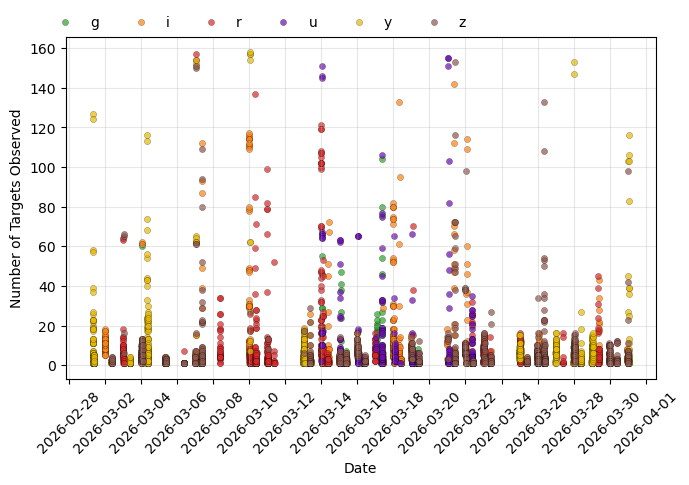

In [ ]:
visits_in_twilight = [v for v in visit_exposure_groups.values() if v['twilight_overlap']]
print(f"Total visits in twilight windows: {len(visits_in_twilight)}")

# Build compact plotting table
plot_df = pd.DataFrame([
    {
        "chile_time": v["chile_time"],
        "n_targets": len(v["targets"]),
        "filter": v["filter"],
        "exposure_time": v["exposure_time"],
        "visit_id": v["visit_id"],
    }
    for v in visits_in_twilight
]).sort_values("chile_time")

# Optional: rolling trend (smooths dense regions)
plot_df["n_targets_roll"] = (
    plot_df.set_index("chile_time")["n_targets"]
    .rolling("12H", min_periods=1).mean()
    .values
)

# Rubin/LSST-like filter colors
filter_colors = {
    "u": "#6a0dad",  # violet/near-UV
    "g": "#2ca02c",  # green
    "r": "#d62728",  # red
    "i": "#ff7f0e",  # orange
    "z": "#8c564b",  # brown-red
    "y": "#e6b800",  # yellow-gold
}

fig, ax = plt.subplots(figsize=(7, 5))

for filt, g in plot_df.groupby("filter"):
    ax.scatter(
        g["chile_time"],
        g["n_targets"],
        s=20 ,  # size encodes exposure
        alpha=0.7,
        color=filter_colors.get(filt, "gray"),
        edgecolor="black",
        linewidth=0.2,
        label=filt
    )

ax.set_xlabel(f'Date')
ax.set_ylabel('Number of Targets Observed')
# ax.set_title(f'OpSim Visits in Twilight Windows - {visit_chile_time.strftime("%B %Y")}')
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=45)
ax.grid(alpha=0.3)
ax.legend(ncol=6, bbox_to_anchor=(0.7, 1.1), framealpha=0 )
plt.tight_layout()
plt.show()
# fig.savefig(f'{pathToPlots}/Skyfield/plots/visits_in_twilight_{visit_chile_time.strftime("%Y%m")}.png')


So far, we've collected all the data that we need in 'visits_in_twilight' dataframe: visits data for twilight times with targets observed in each exposure. We conclude the second part of the tutorial by writing this into a .fits file for future use.

In [ ]:
utils.create_exposure_windows(visits_in_twilight)

Written 48324 rows to twilight_visits_november2025.fits
FITS columns: ['visit_id', 'mjd', 'chile_time', 'exposure_time', 'num_exposures', 'filter', 'field_ra', 'field_dec', 'target_id', 'target_ra', 'target_dec', 'five_sigma_depth', 'seeing', 'sky_brightness']
